# Applied Exercise 7 - Multiple testing on Carseats data

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from ISLP import load_data
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

In [8]:
Carseats = load_data("Carseats")
quant_vars = ["CompPrice", "Income", "Advertising", "Population", "Price", "Age", "Education"]

pvalues = {}

for var in quant_vars:
    X = sm.add_constant(Carseats[var])
    model = sm.OLS(Carseats["Sales"], X).fit()
    pvalues[var] = model.pvalues[var]

pvalues = pd.Series(pvalues)

print("=" * 60)
print("MULTIPLE TESTING for coefficients of regression = 0")
print("=" * 60)
print("\nP-values:")
print(pvalues)

MULTIPLE TESTING for coefficients of regression = 0

P-values:
CompPrice      2.009398e-01
Income         2.309670e-03
Advertising    4.377677e-08
Population     3.139816e-01
Price          7.618187e-21
Age            2.788950e-06
Education      2.999442e-01
dtype: float64


In [9]:
print("\nIndividual α = 0.05. Predictors below 0.05:")
print(pvalues[pvalues < 0.05])


Individual α = 0.05. Predictors below 0.05:
Income         2.309670e-03
Advertising    4.377677e-08
Price          7.618187e-21
Age            2.788950e-06
dtype: float64


In [10]:
reject_fwer, p_fwer, _, _ = multipletests(pvalues, alpha=0.05, method="bonferroni")

print("\nUsing Bonferroni Correction, FWER = 0.05")
print(pvalues.index[reject_fwer])


Using Bonferroni Correction, FWER = 0.05
Index(['Income', 'Advertising', 'Price', 'Age'], dtype='object')


In [11]:
reject_fdr, p_fdr, _, _ = multipletests(pvalues, alpha=0.2, method="fdr_bh")

print("\nUsing Benjamini–Hochberg procedure, FDR = 0.2")
print(pvalues.index[reject_fdr])


Using Benjamini–Hochberg procedure, FDR = 0.2
Index(['Income', 'Advertising', 'Price', 'Age'], dtype='object')


In general, individual α gives most rejections, FWER gives fewest rejections and FDR gives somewhere in between. For this data split, we see that all three yield same results.

# Applied Exercise 8 - Multiple Testing on a simulated dataset

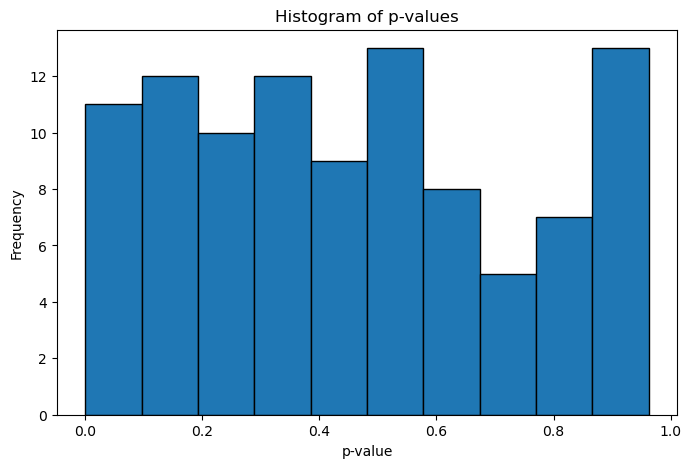

MULTIPLE TESTING
(b) Individual α = 0.05: 4 rejections
(c) FWER = 0.05:         0 rejections
(d) FDR = 0.05:          0 rejections
(e) FWER on best 10:     0 rejections
(e) FDR on best 10:      0 rejections


In [12]:
rng = np.random.default_rng(1)
n, m = 20, 100
X = rng.normal(size=(n, m))

# One-sample t-test for each fund manager
pvalues = np.array([ttest_1samp(X[:, j], 0).pvalue for j in range(m)])

plt.figure(figsize=(8, 5))
plt.hist(pvalues, bins=10, edgecolor="black")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.title("Histogram of p-values")
plt.show()

# Individual Type I error = 0.05
reject_individual = pvalues < 0.05

# FWER = 0.05
reject_fwer, _, _, _ = multipletests(pvalues, alpha=0.05, method="bonferroni")

# FDR = 0.05
reject_fdr, _, _, _ = multipletests(pvalues, alpha=0.05, method="fdr_bh")

# Cherry-pick the 10 best-performing managers
best10 = np.argsort(X.mean(axis=0))[-10:]
p_best10 = pvalues[best10]

reject_fwer_10, _, _, _ = multipletests(p_best10, alpha=0.05, method="bonferroni")
reject_fdr_10, _, _, _ = multipletests(p_best10, alpha=0.05, method="fdr_bh")

print("=" * 60)
print("MULTIPLE TESTING")
print("=" * 60)
print(f"(b) Individual α = 0.05: {reject_individual.sum()} rejections")
print(f"(c) FWER = 0.05:         {reject_fwer.sum()} rejections")
print(f"(d) FDR = 0.05:          {reject_fdr.sum()} rejections")
print(f"(e) FWER on best 10:     {reject_fwer_10.sum()} rejections")
print(f"(e) FDR on best 10:      {reject_fdr_10.sum()} rejections")

- Although all 100 null hypotheses are true, testing each one separately at α = 0.05 produces several false discoveries. Controlling the FWER or FDR at 0.05 eliminates these rejections.
- Cherry-picking the 10 best-performing managers before testing is misleading because the selection was based on the same data used for inference.
- Looking at all 100 managers first and then choose the 10 that look best makes them look good in the data and testing only those 10 makes the results look better than they really are. This introduces selection bias: The selection process itself has influenced which people are being tested, so the final results are not a fair representation of all 100 managers.